In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import cluster
from sklearn.preprocessing import MinMaxScaler

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/game_usage.csv')

In [ ]:
x = data['time spent']
y = data['game level']

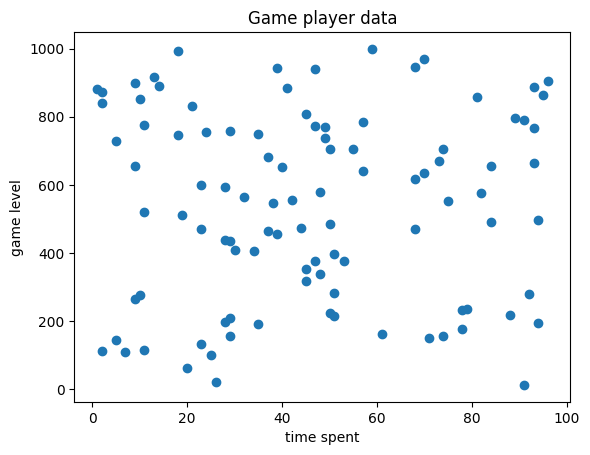

In [ ]:
# 산포도 그래프 - 게임 이용자 분석
plt.title('Game player data')
plt.xlabel('time spent')
plt.ylabel('game level')
plt.scatter(x,y)
plt.show()

In [ ]:
def kmeans_predict_plot(data, k):
  # 모델생성
  model = cluster.KMeans(n_clusters=k,random_state=42)
  # 학습
  model.fit(data)
  # 예측
  labels = model.predict(data)

  colors = np.array(['red','green','blue','magenta'])
  plt.scatter(data[:,0],data[:,1],color=colors[labels])

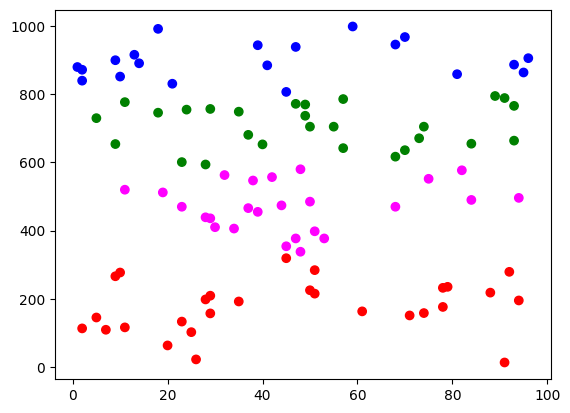

In [ ]:
data = np.column_stack((x,y))
kmeans_predict_plot(data,4)

In [ ]:
# MinMaxScaler : 범위(0~1), 거리기반 알고리즘에 적용
scaler = MinMaxScaler()

scaler.fit(data)

n_data = scaler.transform(data)

In [ ]:
n_data[:,0].min(),data[:,0].max()

(np.float64(0.0), np.int64(96))

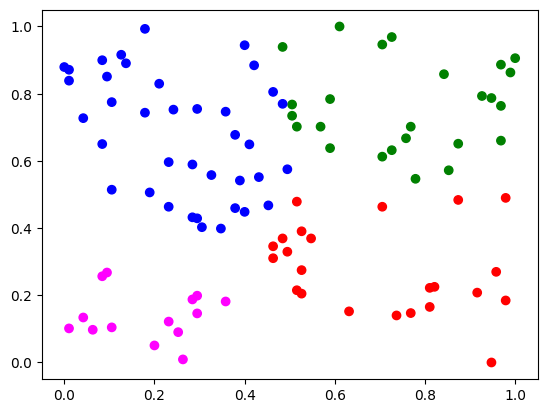

In [ ]:
kmeans_predict_plot(n_data,4)

# 택배시스템 최적화

- 군집을 이용해 데이터에 숨어있는 특징을 파악하고, 좀 더 체계적이고 효과적으로 물류 창고 설치 위치를 정하고자 분석

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# 인천 연안의 위치한 택배 위치 데이터 (일렬번호, 위도,경도)
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Delivery.csv')
data.head()

,Num,Latitude,Longitude
0,1,37.336803,126.712836
1,2,37.501303,126.787808
2,3,37.522501,126.777363
3,4,37.511178,126.743209
4,5,37.508776,126.738469


In [ ]:
xy = np.array(data)
x = xy[:,1:]

In [ ]:
# km.inertia_ : 각 데이터 포인트가 자신이 속한 클러스트의 중심적으로부터 얼마나 떨어져있는지를 나타냄
def elbow(x,n):
  sse = []
  for i in range(1, n+1):
    km = KMeans(n_clusters=i)
    km.fit(x)
    sse.append(km.inertia_)
  plt.figure(figsize=(12,9))
  plt.plot(range(1,n+1),sse,marker='o')
  plt.xlabel('cluster number')
  plt.ylabel('SSE')
  plt.show()

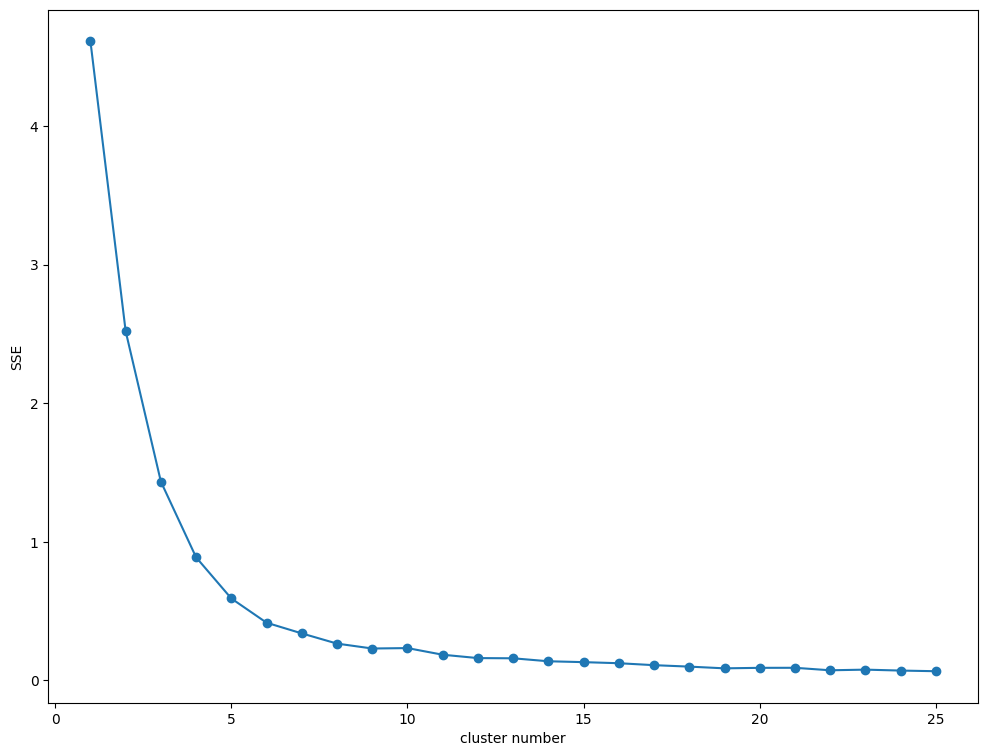

In [ ]:
elbow(x,25)

In [ ]:
k = 5
c_x = np.random.choice(x[:,0],k)
c_y = np.random.choice(x[:,1],k)
c = np.array(list(zip(c_x,c_y)))
print(c)

[[ 37.290316 126.711397]
 [ 37.312445 126.720096]
 [ 37.316104 126.628301]
 [ 37.516068 126.727288]
 [ 37.342471 126.740958]]


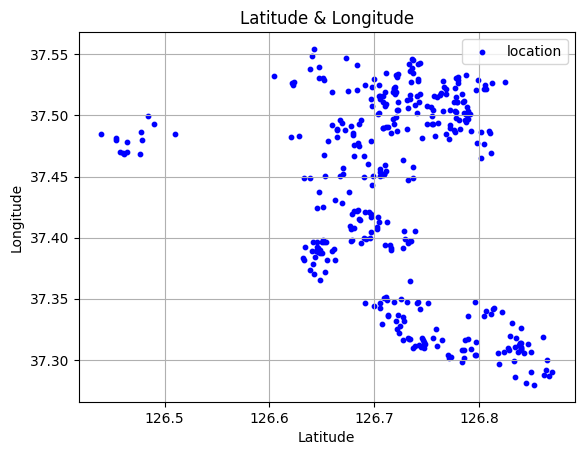

In [ ]:
# 위에 5개의 군집점과 택배 위치 데이터를 시각화
lat = data['Latitude']
lon = data['Longitude']
plt.title('Latitude & Longitude')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.scatter(lon,lat,c='blue',s=10,label='location')
plt.legend(loc='best')
plt.grid()
plt.show()

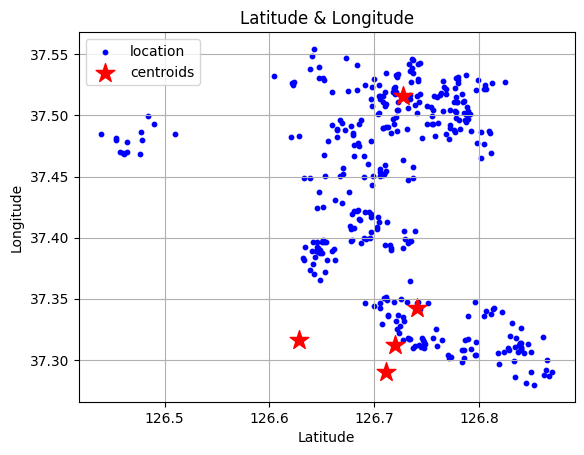

In [ ]:
# 위에 5개의 군집점과 택배 위치 데이터를 시각화
lat = data['Latitude']
lon = data['Longitude']
plt.title('Latitude & Longitude')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.scatter(lon,lat,c='blue',s=10,label='location')
plt.scatter(c_y,c_x,marker='*',color='red',s=200,label='centroids')
plt.legend(loc='best')
plt.grid()
plt.show()

In [ ]:
# 각 군집에 속한 데이터의 평균을 계산하여 중심을 갱신하기 때문에,
# 거리를 구하는 함수를 설정. 이후 거리함수는 유클리드 거리공식을 이용.

def distance(A,B):
  return np.sqrt(np.sum(np.power((A,B),2)))

In [ ]:
c_old = np.zeros(c.shape)
clusters = np.zeros(len(x))

In [ ]:
flag = distance(c,c_old)

In [ ]:
print(flag)

295.3790052936114


In [ ]:
c_island = (37.38,126.4)
c_x = np.random.choice(x[:,0],k-1)
c_y = np.random.choice(x[:,1],k-1)
c = list(zip(c_x,c_y))
c.append(c_island)
c = np.array(c)
print(c)

[[ 37.528772 126.840328]
 [ 37.480889 126.811066]
 [ 37.412694 126.75811 ]
 [ 37.506977 126.839768]
 [ 37.38     126.4     ]]


In [ ]:
from copy import deepcopy #numpy 배열 c를 단순히 복사하면 두 변수가 같은 메모리 주소를 가르치게 된다

In [ ]:
distances = []
while flag != 0:
  for i in range(len(x)):
    for j in range(k):
      temp = distance(x[i],c[j])
      distances.append(temp)
    cluster = np.argmin(distances)
    clusters[i] = cluster
    distances = []

  c_old = deepcopy(c)

  for i in range(k):
    points = [x[j] for j in range(len(x)) if clusters[j]==i]

    if len(points) > 0:
      points = np.array(points)
      c[i][0] = np.mean(points[:,0])
      c[i][1] = np.mean(points[:,1])
  flag = distance(c,c_old)

TypeError: 'list' object is not callable

In [ ]:
plt.figure(gifsize=(8,6))
ply.scatter(x[clusters==0,1],x[clusters==0,0],s=50,c='red',edgecolor='black',label='A')
ply.scatter(x[clusters==1,1],x[clusters==1,0],s=50,c='yelllow',edgecolor='black',label='B')
ply.scatter(x[clusters==2,1],x[clusters==2,0],s=50,c='pink',edgecolor='black',label='C')
ply.scatter(x[clusters==3,1],x[clusters==3,0],s=50,c='red',edgecolor='black',label='D')
ply.scatter(x[clusters==4,1],x[clusters==4,0],s=50,c='blue',edgecolor='black',label='E')
plt.scatter(c[:,1],c[:,0],s=250,marker='*',c='black')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import folium as gm

In [ ]:
g_map = gm.Map(location=[37.428631,126.596539],zoom_start=12)
g_map

In [ ]:
m_color=['blue','red','green','puple','orange']

In [ ]:
for i in range(k):
  for i in range(len(x[clusters==i,1])):
    marker = gm.CircleMarker(x[clusters==i,0[j],x[clusters==i,1][j]],
                             radius=3,color=m_color[i])
    marker.add_to(g_map)
g_map

In [ ]:
for i in range(len(c)):
  marker = gm.Marker([c[i][0],c[i][1]],popup='kmeans point',
                           icon=gm.Icon(icon='star',color='black'))
  marker.add_to(g_map)

g_map

In [ ]:
for i in range(len(c)):
  marker = gm.Marker([c[i][0],c[i][1]],radius=100,popup='kMeans point',color=m_color,fill_color=m_color[i])
  marker.add_to(g_map)

g_map

# 3. 온라인 쇼핑몰 고객 100명 분석
- 적당한 수의 그룹으로 묶고, 그룹별 특성 확인

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import cluster

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/example_cluster.csv')
data

,var_1,var_2
0,3.264413,6.929164
1,0.220814,2.251631
2,-8.786197,-8.333582
3,-0.008547,2.630791
4,4.912903,6.888520
...,...,...
995,4.678232,7.704404
996,5.250715,6.930948
997,-11.818752,-5.609853
998,0.613725,3.809334


<Axes: xlabel='var_1', ylabel='var_2'>

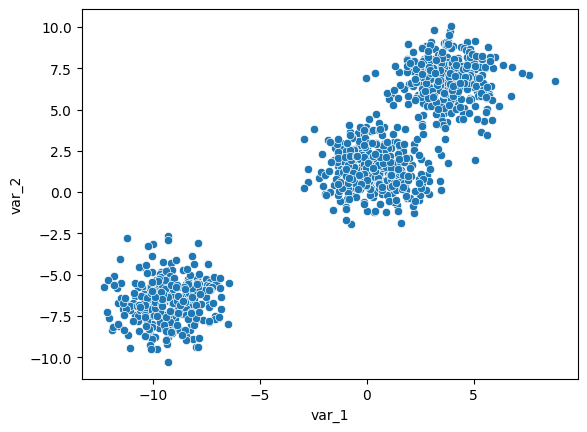

In [ ]:
sns.scatterplot(x='var_1',y='var_2',data=data)

In [ ]:
# 모델 객체 생성
kmeans_model = KMeans(n_clusters=3,random_state=100)

In [ ]:
# 학습
kmeans_model.fit(data)

KMeans(n_clusters=3, random_state=100)

In [ ]:
# 예측
data['label']=kmeans_model.predict(data)

<Axes: xlabel='var_1', ylabel='var_2'>

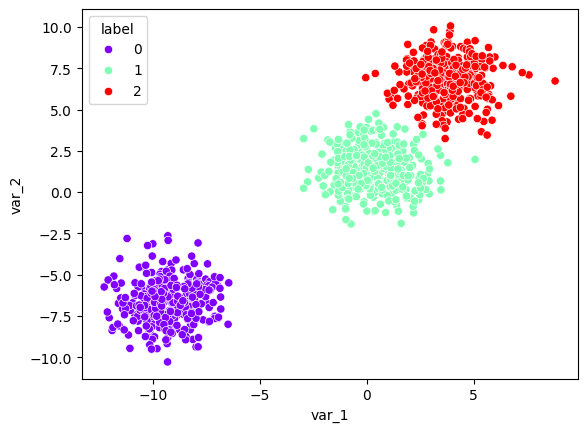

In [ ]:
# 예측결과를 scatterplot()으로 확인
sns.scatterplot(x='var_1',y='var_2',data=data,hue='label',palette='rainbow')

In [ ]:
# 엘보우 기법으로 최적의 k값 구하기
# intertia_(이너셔) : 각 그룹에서의 중심과 각 그룹에 해당하는 데이터 간의 거리에 대한 합을 계산
# 모델이 학습을 진행 할 때, 자동적으로 이너셔값을 계산

kmeans_model.inertia_

3090.033237076663

In [ ]:
temp_model = KMeans(n_clusters=500,random_state=100)
temp_model.fit(data)
temp_model.inertia_

6.3412059092392274

In [ ]:
distance=[]
for k in range(2,10):
  k_model=KMeans(n_clusters=k)
  k_model.fit(data)
  distance.append(k_model.inertia_)

<Axes: >

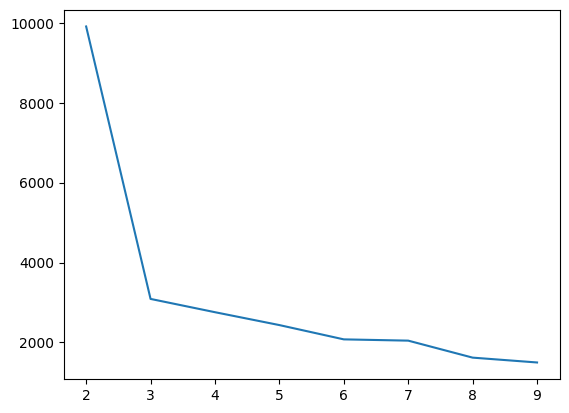

In [ ]:
sns.lineplot(x=range(2,10),y=distance)

In [ ]:
# 고객 데이터 (실습)
data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/customer.csv')

In [ ]:
data['cc_num'].nunique()

100

In [ ]:
data['category'].nunique()

11

In [ ]:
# 각 고객이 어떤 범주에 얼마만큼 지불했는지 계산 후,
# k-means 군집화로 비슷한 특성을 가진 고객끼리 묶어야함
# 범주별 금액을 계산할려면 category 변수를 더미 변수로 변환해야함
customer_dummy = pd.get_dummies(data,columns=['category'])

In [ ]:
customer_dummy.head()

,cc_num,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel
0,2703186189652095,4.97,False,False,False,False,False,False,False,True,False,False,False
1,630423337322,107.23,False,False,False,True,False,False,False,False,False,False,False
2,38859492057661,220.11,True,False,False,False,False,False,False,False,False,False,False
3,3534093764340240,45.00,False,False,True,False,False,False,False,False,False,False,False
4,375534208663984,41.96,False,False,False,False,False,False,False,True,False,False,False


In [ ]:
# 범주별로 얼마만큼의 금액을 사용했는지 계산
# 더미변수로 변환된 영역에 atm변수의 값을 곱해서 계산

cat_list = customer_dummy.columns[2:]

In [ ]:
for i in cat_list:
  customer_dummy[i] = customer_dummy[i]*customer_dummy['amt']

In [ ]:
customer_dummy

,cc_num,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel
0,2703186189652095,4.97,0.00,0.0,0.0,0.00,0.00,0.0,0.0,4.97,0.0,0.00,0.0
1,630423337322,107.23,0.00,0.0,0.0,107.23,0.00,0.0,0.0,0.00,0.0,0.00,0.0
2,38859492057661,220.11,220.11,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0
3,3534093764340240,45.00,0.00,0.0,45.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0
4,375534208663984,41.96,0.00,0.0,0.0,0.00,0.00,0.0,0.0,41.96,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240449,4716561796955522,4.93,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,4.93,0.0
240450,30074693890476,140.12,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,140.12,0.0
240451,30404291151692,37.79,0.00,0.0,0.0,0.00,37.79,0.0,0.0,0.00,0.0,0.00,0.0
240452,4922710831011201,17.50,17.50,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0


In [ ]:
customer_agg = customer_dummy.groupby('cc_num').sum()

In [ ]:
# k-means 군집화는 거리 기반 알고리즘이기 때문에 데이터 스케일의 영향을 받음

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler_df = pd.DataFrame(scaler.fit_transform(customer_agg),
                         columns = customer_agg.columns,
                         index=customer_agg.index)

In [ ]:
scaler_df.head()
# 평균에 가까울수록 0에 근접한 값을 보여주게 되고,
# 더 많이 사용했으면, 양수를 , 더 적게 사용하면 마이너스를 보인다

,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel
cc_num,,,,,,,,,,,,
60495593109,-1.402327,-1.135617,-0.971069,-1.000180,-1.118217,-1.561756,-1.145051,-1.276913,-1.124693,-1.070260,-1.141424,-0.619930
571365235126,1.079407,0.414075,0.168880,2.090013,0.767268,1.040236,0.844969,1.127922,1.210503,1.807350,0.659967,-0.222587
571465035400,1.200151,0.747127,1.622968,-0.606627,0.439476,1.376630,2.126364,0.378610,-0.196523,0.127825,1.299938,2.766891
630412733309,-1.474915,-1.129427,-1.539741,-0.930355,-1.079803,-1.222903,-1.572733,-1.516610,-1.274986,-1.185705,-1.166127,-0.601675
630423337322,0.901491,0.257905,-0.320220,2.083588,0.540547,0.705908,1.097814,0.955178,1.198524,1.640103,0.578781,-0.484796


In [ ]:
distance = []
for k in range(2,10):
  k_model = KMeans(n_clusters=k)
  k_model.fit(scaler_df)
  labels = k_model.predict(scaler_df)
  distance.append(k_model.inertia_)

<Axes: >

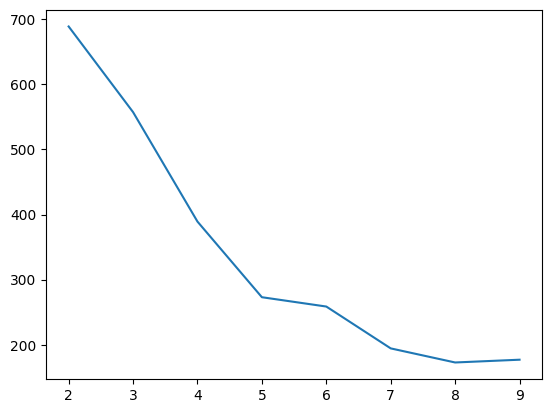

In [ ]:
sns.lineplot(x=range(2,10),y=distance)

In [ ]:
# 실루엣 개수 : 엘보우 기법에서 적절한 클러스트 수를 찾지 못했을 때, 대안으로 사용
# 엘보우 기법보다 시간이 오래 걸리는 단점

from sklearn.metrics import silhouette_score

silhouette = []
for k in range(2,10):
  k_model = KMeans(n_clusters=k,random_state=100)
  k_model.fit(scaler_df)
  labels = k_model.predict(scaler_df)
  silhouette.append(silhouette_score(scaler_df,labels))


<Axes: >

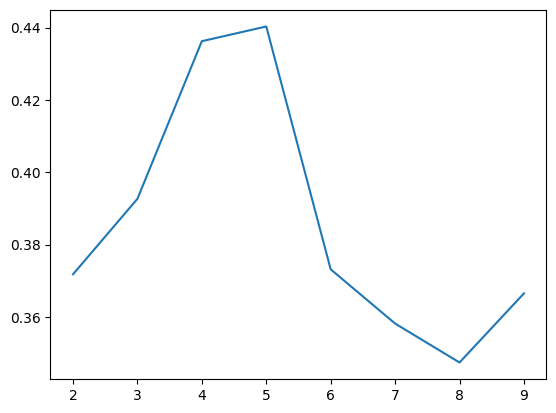

In [ ]:
# 실루엣 개수는 높은 값일수록 더 좋은 분류를 의미
sns.lineplot(x=range(2,10),y=silhouette)

In [ ]:
# 모델 생성
model = KMeans(n_clusters=5)
# 학습
model.fit(scaler_df)
# 예측
labels = model.predict(scaler_df)

In [ ]:
scaler_df['labels'] = labels

In [ ]:
scaler_df_mean = scaler_df.groupby('labels').mean()
scaler_df_count = scaler_df.groupby('labels').count()['category_travel']

In [ ]:
scaler_df_count = scaler_df_count.rename('count')

In [ ]:
scaler_df_all = scaler_df_mean.join(scaler_df_count)

In [ ]:
scaler_df_all

,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel,count
labels,,,,,,,,,,,,,
0,0.469189,0.277318,0.150723,1.048777,0.307398,0.645205,0.461968,0.684302,0.535094,0.610172,0.200707,-0.237715,34
1,-0.406078,-0.350565,-0.046516,-0.224490,-0.353360,-0.485074,-0.348980,-0.102472,-0.368184,-0.344612,-0.351064,-0.249067,27
2,2.246930,2.636017,2.102489,-0.339554,2.553883,1.526188,1.118452,1.527483,2.410239,2.042583,2.581577,-0.269260,7
3,1.000533,0.776166,1.036432,-0.749213,0.310577,1.175961,1.794775,-0.011510,-0.311453,-0.093603,0.989477,3.050970,8
4,-1.196712,-1.026042,-1.119896,-0.884442,-0.886358,-1.205458,-1.186326,-1.295826,-0.943013,-1.041274,-0.972173,-0.321492,24


# iris k-means 군집화

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [25]:
data = load_iris()

In [26]:
# 꽃잎의 길이와 너비
x = data.data[:,[2,3]]

In [27]:
# model
# init='k_means++' : 첫번째 중심은 무작위로 선택하지만, 두번째 중심부터는 이미 선택된
#                    중심점들과 거리가 먼 데이터포인터일수록 뽑힐 확률이 높게 설정됨
# n_init = 10 : 총 10번 실행, 결과중에서 inertia 값이 가장 낮은 모델을 자동 선택
model = KMeans(n_clusters=3,init='k-means++',random_state=42,n_init=10)

In [28]:
labels = model.fit_predict(x)

In [29]:
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0]


In [30]:
centers = model.cluster_centers_

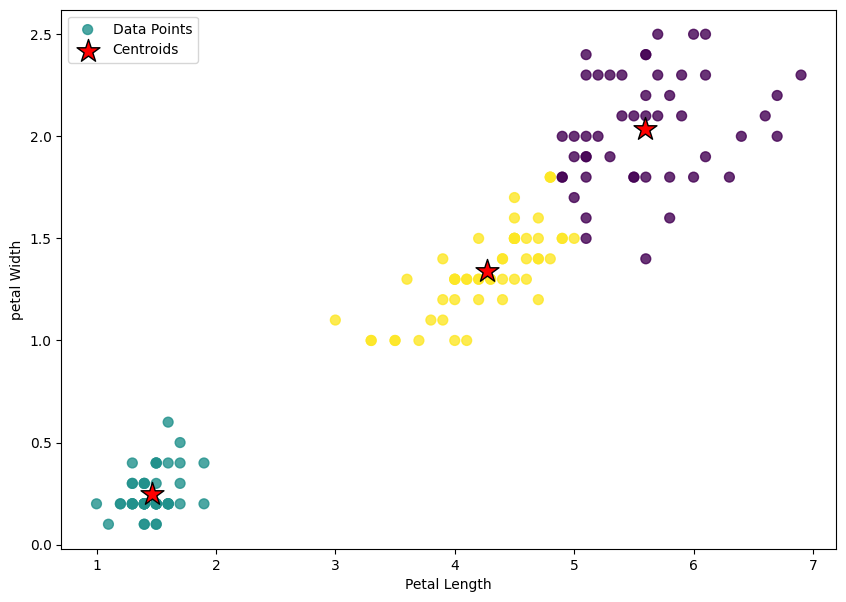

In [31]:
plt.figure(figsize=(10,7))
plt.scatter(x[:,0],x[:,1],c=labels,cmap='viridis',s=50,alpha=0.8,label='Data Points')
plt.scatter(centers[:,0],centers[:,1],c='red',marker='*',s=300,edgecolors='black',label='Centroids')
plt.xlabel('Petal Length')
plt.ylabel('petal Width')
plt.legend()
plt.show()